# How does a retailer like Kalpa make money, who asks the data team for which number, and how is each number worked out?

**Week 1, Monday, the story that opens the day (chapter 0 of 6).** Most of the room has shopped
in a store and on an app without seeing the business from behind the till. One scene from the
morning's story, a Retail-Plus member's Saturday basket at Kalpa Retail, is enough to work out
the metrics a retail data team is asked for, each as a formula with a worked number.
Every number here is **invented**, taken from the round illustrative numbers of the retail
dossier so the arithmetic stays easy, and none of them is Kalpa's data or a real company's.

**Who needs the answer.** Everyone who asks the data team for a number needs to know which
number they are asking for. Meera Raghavan, the CEO, asks for revenue and, before she signs any
acquisition budget, for how long it takes to pay back. Anand Iyer, the finance controller, asks
for net revenue and margin. The marketing lead asks for conversion and the cost
of winning a customer, and the head of Retail-Plus, Kalpa's paid membership tier, asks for
retention. A number worked out on a definition its reader did not ask for sends them to the
wrong decision, so each formula below comes with the question it answers and the person who
asks it.

**The questions on the way.**

1. Where does Rs 100 of what customers order go before Kalpa keeps a profit?
2. What does one Saturday basket add towards the costs that stay fixed?
3. What share of the app's Saturday sessions end in an order?
4. How do customers, orders and prices multiply into a month's revenue?
5. How many of January's new customers order again in each later month?
6. How many months does a new customer take to pay back what winning them cost?

The metrics at stake are the ten on the domain card,
`cheatsheets/C2_W01_D01_retail_domain_card_STUDENT.pdf`, and sections 3 and 5 of the retail
dossier, `study-notes/C2_W01_D01_domain_retail_STUDENT.md`, carry the long version of each.
This is the day's first notebook, and chapter 1 then opens Kalpa's own 30 orders.

> **Kavya's review.** Before I read any number, I read what it is divided by, over which
> window, and who asked for it. Practise saying all three beside every formula below.

**Setup.** The first cell finds the shared helper, `c2kit`, by walking up from this folder
until it reaches `scripts/`. No data file is needed, since every number below is invented and
typed in.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
print("helper loaded; every number below is invented")

helper loaded; every number below is invented


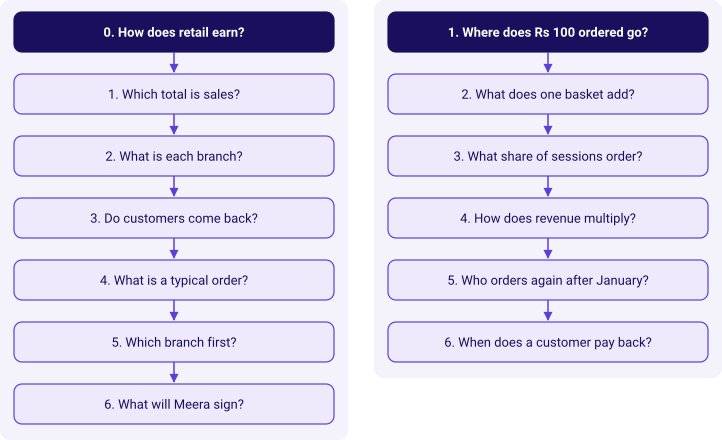

In [2]:
kit.side_by_side(
    kit.vflow(['0. How does retail earn?', '1. Which total is sales?', '2. What is each branch?', '3. Do customers come back?', '4. What is a typical order?', '5. Which branch first?', '6. What will Meera sign?'], lit=0, show=False),
    kit.vflow(['1. Where does Rs 100 ordered go?', '2. What does one basket add?', '3. What share of sessions order?', '4. How does revenue multiply?', '5. Who orders again after January?', '6. When does a customer pay back?'], lit=0, show=False),
)

## 1. Where does Rs 100 of what customers order go before Kalpa keeps a profit?

Gross merchandise value (GMV) is the value of everything customers ordered, at the prices
charged. Net revenue is what the business earns from the goods, and the two are different
numbers: on Rs 100 of invented GMV, net revenue is Rs 80, and what makes up the Rs 20 between
them is the question chapter 1 opens on Kalpa's own orders. From net revenue, the profit and
loss statement (the P&L) steps down one line at a time. Rs 60 pays for the goods, the cost of
goods sold (COGS), and leaves the gross margin. Rs 12.50 goes on the costs that come with every
order (picking, delivery, handling returns, the payment fee and the offers that bring a
customer back) and leaves the contribution. Rs 5 pays the fixed costs of stores, warehouses,
technology, head office and the budget that wins new customers, and what remains is EBITDA,
earnings before interest, tax, depreciation and amortisation. The finance controller asks for
every line, since each one says whether a different part of the business pays its way.

**Predict before you run.** Of Rs 100 ordered, how much is left as EBITDA?

- a) About Rs 25, a quarter of what was ordered.
- b) About Rs 10, a tenth of what was ordered.
- c) Rs 2.50.
- d) Nothing, since retail runs at a loss.

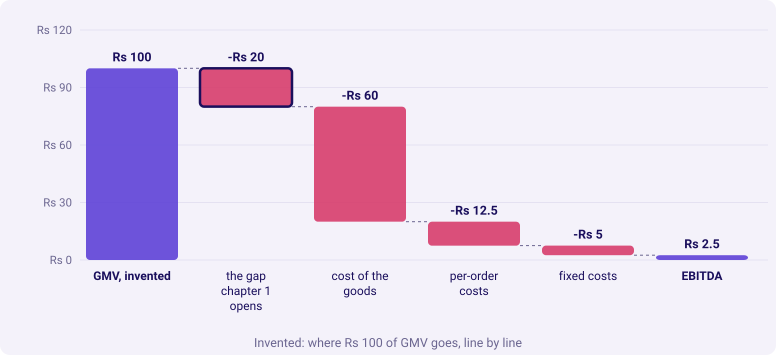

line of the P&L,Rs left of 100,what it answers
net revenue,80,what the business earns from the goods
gross margin,20,what the goods earn over their cost
contribution,7.5,what each order adds towards the fixed costs
EBITDA,2.5,"what is left before interest, tax and depreciation"


In [3]:
gmv = 100.0                                   # invented, the dossier's illustrative Rs 100
steps = [("the gap chapter 1 opens", -20), ("cost of the goods", -60),
         ("per-order costs", -12.5), ("fixed costs", -5)]
names = ["net revenue", "gross margin", "contribution", "EBITDA"]
answers = ["what the business earns from the goods", "what the goods earn over their cost",
           "what each order adds towards the fixed costs",
           "what is left before interest, tax and depreciation"]
levels, left = {}, gmv
for (label, change), name in zip(steps, names):
    left += change
    levels[name] = left
rs = lambda v: ("-" if v < 0 else "") + f"Rs {abs(v):g}"
kit.bridge(("GMV, invented", gmv), steps, end_label="EBITDA", lit=(0,), fmt=rs,
           title="Invented: where Rs 100 of GMV goes, line by line")
kit.table(["line of the P&L", "Rs left of 100", "what it answers"],
          [(n, f"{levels[n]:g}", a) for n, a in zip(names, answers)],
          caption="Invented numbers: the P&L from GMV to EBITDA")

**What happened.** The answer is c: of Rs 100 ordered, Rs 2.50 is left as EBITDA. Net revenue
is Rs 80, gross margin Rs 20 (25 percent of net revenue) and contribution Rs 7.50. A retailer
keeps a thin slice, so a price cut that brings no extra volume can give away the whole profit.

In [4]:
kit.check("net revenue is Rs 80 of every Rs 100 of GMV", levels["net revenue"] == 80)
kit.check("gross margin is 25 percent of net revenue",
          levels["gross margin"] / levels["net revenue"] == 0.25)
kit.check("EBITDA is Rs 2.50", levels["EBITDA"] == 2.5)

## 2. What does one Saturday basket add towards the costs that stay fixed?

The member's basket shows Rs 1,800 at the checkout, which is its GMV, and Kalpa's net revenue
on it is Rs 1,600 (invented). Contribution is the gross margin less the costs that come with
each order: picking and delivery, the payment fee, handling returns averaged over every order,
and the retention offers that bring a customer back. The cost of winning a new customer stays
out of it, in the acquisition cost of section 6. The finance controller and the category buyers
ask for contribution, because it is what one more order adds towards the costs that do not
change with one more order.

**Predict before you run.** What does the member's order contribute?

- a) Rs 1,800, what the member paid.
- b) Rs 150.
- c) Rs 400, the gross margin.
- d) Rs 1,600, the net revenue.

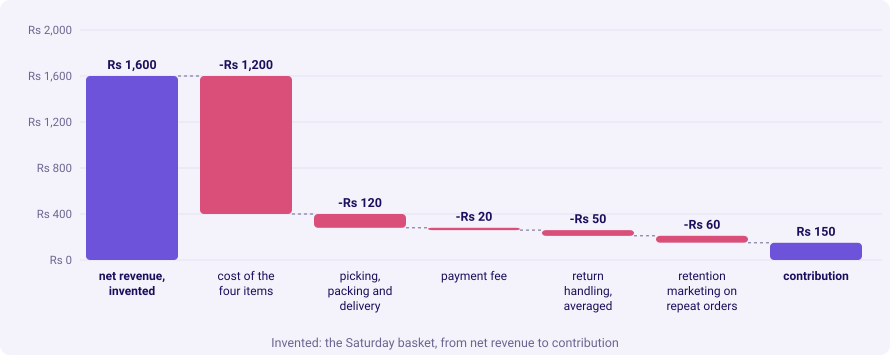

gross margin Rs 400 (25% of net revenue), contribution Rs 150 (9.4% of net revenue)


In [5]:
net_revenue = 1600                                          # invented, the basket's net revenue
basket = {"cost of the four items": -1200, "picking, packing and delivery": -120,
          "payment fee": -20, "return handling, averaged": -50,
          "retention marketing on repeat orders": -60}     # invented
gross_margin = net_revenue + basket["cost of the four items"]
contribution = net_revenue + sum(basket.values())
kit.bridge(("net revenue, invented", net_revenue), list(basket.items()), end_label="contribution",
           title="Invented: the Saturday basket, from net revenue to contribution")
print(f"gross margin {kit.rupees(gross_margin)} ({gross_margin / net_revenue:.0%} of net revenue), "
      f"contribution {kit.rupees(contribution)} ({contribution / net_revenue:.1%} of net revenue)")

**What happened.** The answer is b: the order contributes Rs 150, 9.4 percent of its net
revenue. Delivery costs about the same whatever is in the bag, so a small basket carries the
same trip on far less margin, which is the arithmetic behind a minimum order for free delivery.

In [6]:
kit.check("gross margin percent = (net revenue less COGS) / net revenue = 25 percent",
          gross_margin / net_revenue == 0.25, f"{gross_margin / net_revenue:.0%}")
kit.check("contribution on the basket is Rs 150", contribution == 150, kit.rupees(contribution))

## 3. What share of the app's Saturday sessions end in an order?

Conversion is orders over visits, both counted on the same days, and the app counts each visit
as a session. On the invented Saturday the app had 80,000 sessions, 8,000 of them reached a
cart and 2,000 became orders. Each step of the funnel is the next stage over the one before, so
the funnel shows where shoppers stopped. Marketing and the app's product team ask for
conversion, to see whether a campaign brought buyers or only visits.

**Predict before you run.** What share of the Saturday's 80,000 sessions ended in an order?

- a) 25 percent.
- b) 10 percent.
- c) 2.5 percent.
- d) 40 percent.

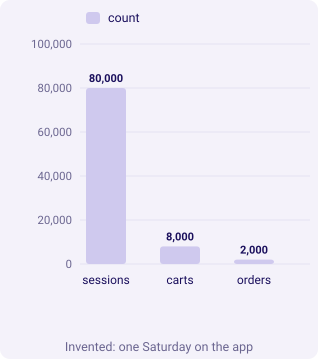

step of the funnel,rate
sessions that reached a cart,10.0%
carts that became orders,25.0%
"sessions that became orders, the conversion",2.5%


In [7]:
funnel = [("sessions", 80000), ("carts", 8000), ("orders", 2000)]           # invented
f = dict(funnel)
conversion = f["orders"] / f["sessions"]
funnel_steps = [("sessions that reached a cart", f["carts"] / f["sessions"]),
                ("carts that became orders", f["orders"] / f["carts"]),
                ("sessions that became orders, the conversion", conversion)]
kit.columns([n for n, _ in funnel], [("count", [v for _, v in funnel])],
            title="Invented: one Saturday on the app")
kit.table(["step of the funnel", "rate"], [(n, f"{r:.1%}") for n, r in funnel_steps],
          caption="Invented: the funnel's two steps and the conversion they make")

**What happened.** The answer is c: 2,000 orders from 80,000 sessions is a conversion of 2.5
percent. A tenth of the sessions reached a cart and a quarter of the carts became orders, and
the two steps multiply to the conversion, so a fall in conversion can be traced to the step
where shoppers stopped.

In [8]:
kit.check("conversion is 2.5 percent of sessions", conversion == 0.025)
kit.check("the funnel's two steps multiply to the conversion",
          abs(funnel_steps[0][1] * funnel_steps[1][1] - conversion) < 1e-12)

## 4. How do customers, orders and prices multiply into a month's revenue?

The revenue tree splits revenue into branches that multiply: customers, times orders per
customer, times items per order, times price per item, less discounts. In the invented month,
40,000 customers placed 1.25 orders each, of four items, at Rs 450 an item, before a 10 percent
discount. The CEO asks for the tree first, because a revenue number that moves says nothing
about why until it is split, and each branch has an owner: customers belong to marketing,
orders per customer to retention and the membership tier, and items and price to
merchandising.

**Predict before you run.** Which branch does a Retail-Plus membership, with its free delivery
and member prices, set out to move?

- a) Customers.
- b) Orders per customer.
- c) Items per order.
- d) Price per item.

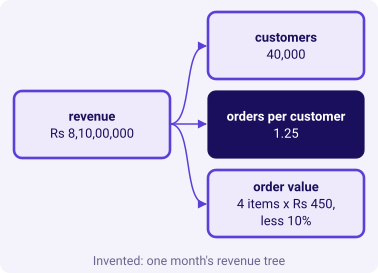

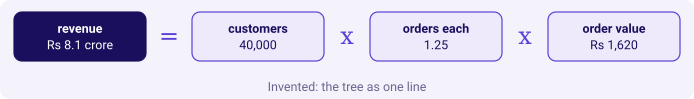

revenue Rs 8,10,00,000, which is Rs 8.1 crore


In [9]:
month = {"customers": 40000, "orders per customer": 1.25, "items per order": 4,
         "price per item": 450, "kept after the discount": 0.90}              # invented
revenue = 1.0
for v in month.values():
    revenue *= v
order_value = month["items per order"] * month["price per item"] * month["kept after the discount"]
kit.driver_tree({"label": "revenue", "note": kit.rupees(revenue), "kind": "known", "children": [
    {"label": "customers", "note": "40,000", "kind": "known"},
    {"label": "orders per customer", "note": "1.25", "kind": "lit"},
    {"label": "order value", "note": "4 items x Rs 450, less 10%", "kind": "known"}]},
    title="Invented: one month's revenue tree")
kit.equation(["revenue\nRs 8.1 crore", "=", "customers\n40,000", "x", "orders each\n1.25", "x",
              "order value\n" + kit.rupees(order_value)], title="Invented: the tree as one line")
print(f"revenue {kit.rupees(revenue)}, which is Rs {revenue / 1e7:.1f} crore")

**What happened.** The answer is b: a membership sets out to bring members back more often,
which is the orders-per-customer branch. The month multiplies to Rs 8.1 crore, 40,000 customers
x 1.25 orders x Rs 1,620 an order, and the same revenue could come from more customers, more
orders each or larger orders, which is why the CEO's first question is which branch moved.

In [10]:
kit.check("the tree multiplies to Rs 8.1 crore", round(revenue) == 81000000, kit.rupees(revenue))
kit.check("customers x orders each x order value gives the same revenue",
          round(month["customers"] * month["orders per customer"] * order_value) == round(revenue))

## 5. How many of January's new customers order again in each later month?

A cohort is the customers who first bought in the same month. Retention in month k is the number
of the cohort's customers who ordered in month k, over the cohort's starting size. January
brought 1,000 new customers (invented), and 380 of them ordered in February, 300 in March and
260 in April. The head of Retail-Plus and marketing ask for retention, because it shows how fast
a month's new customers thin out, which is what a retention programme is paid to slow.

**Predict before you run.** What is the January cohort's retention in March?

- a) 38 percent.
- b) 30 percent.
- c) 26 percent.
- d) 3 percent.

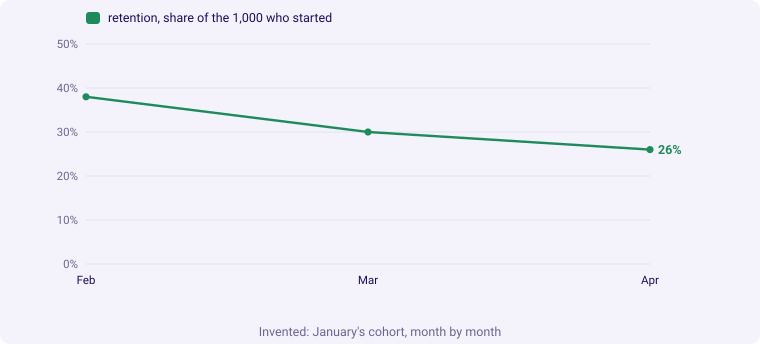

month,the cohort's buyers,retention
Feb,380,38%
Mar,300,30%
Apr,260,26%


In [11]:
cohort = 1000                                                      # invented
buyers = {"Feb": 380, "Mar": 300, "Apr": 260}
retention = {m: b / cohort for m, b in buyers.items()}
kit.line(list(buyers), [("retention, share of the 1,000 who started",
                         [round(r * 100) for r in retention.values()], "good")],
         fmt=lambda v: f"{v:g}%", title="Invented: January's cohort, month by month")
kit.table(["month", "the cohort's buyers", "retention"],
          [(m, buyers[m], f"{r:.0%}") for m, r in retention.items()],
          caption="Invented: January's 1,000 new customers")

**What happened.** The answer is b: 300 of the 1,000 ordered in March, a retention of 30
percent. The cohort holds 38 percent in February, 30 in March and 26 in April, and the
flattening between March and April is the part a retention programme sets out to raise.

In [12]:
kit.check("March retention is 30 percent of the cohort", retention["Mar"] == 0.30)
kit.check("each month's retention sits at or below the month before",
          list(retention.values()) == sorted(retention.values(), reverse=True))

## 6. How many months does a new customer take to pay back what winning them cost?

Customer lifetime value (CLV) is contribution per order, times orders a year, times
years as a customer. Customer acquisition cost (CAC) is acquisition spend over the new customers
it brought, and payback is CAC over the monthly contribution per customer. On invented numbers:
Rs 150 of contribution per order (section 2's basket), 6 orders a year, 2 years, and an invented
campaign of Rs 3 crore that brought 20,000 new customers. The CEO and the finance
controller ask for the payback before they sign an acquisition budget, since it says how long
the spend takes to come back.

**Predict before you run.** How many months does one new customer take to pay back their
acquisition cost?

- a) 10 months.
- b) 20 months.
- c) 24 months, the whole time a customer stays.
- d) It never pays back.

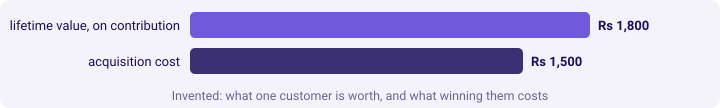

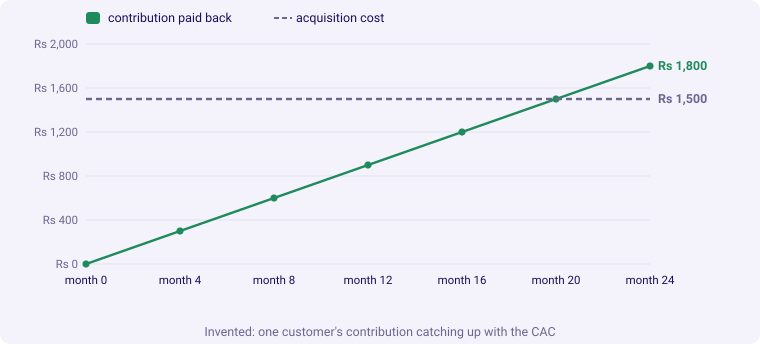

CLV Rs 1,800, CAC Rs 1,500, payback 20 months


In [13]:
per_order, per_year, years = 150, 6, 2                             # invented
clv = per_order * per_year * years
cac = 3_00_00_000 / 20000                                          # invented campaign, Rs 3 crore
monthly = per_order * per_year / 12
payback = cac / monthly
kit.bars([("lifetime value, on contribution", clv), ("acquisition cost", cac)], fmt=kit.rupees,
         lit=(1,), title="Invented: what one customer is worth, and what winning them costs")
months = list(range(0, 25, 4))
kit.line([f"month {m}" for m in months],
         [("contribution paid back", [monthly * m for m in months], "good"),
          ("acquisition cost", [cac] * len(months), "plan")],
         fmt=kit.rupees, title="Invented: one customer's contribution catching up with the CAC")
print(f"CLV {kit.rupees(clv)}, CAC {kit.rupees(cac)}, payback {payback:.0f} months")

**What happened.** The answer is b. Rs 75 of contribution a month repays the Rs 1,500 CAC in
20 of the 24 months a customer stays, so the Rs 1,800 lifetime value clears the acquisition
cost by Rs 300. The Rs 60 of retention marketing inside section 2's contribution is spent on
repeat orders, and the cost of winning the customer sits only in the CAC, so the payback counts
each rupee of marketing once.

In [14]:
kit.check("CLV on contribution is Rs 1,800", clv == 1800)
kit.check("CAC is Rs 1,500", cac == 1500)
kit.check("payback is 20 months", payback == 20)
kit.check("the CLV clears the CAC by Rs 300", clv - cac == 300)

### How are days of inventory, gross margin percent and like-for-like growth worked out?

The domain card carries three more formulas. Days of inventory is average stock at cost over the
cost of goods sold per day, and supply chain and the category buyers ask for it, since stock on
the shelf is cash the business has already paid out. Gross margin percent is net revenue less
the cost of goods, over net revenue, and the finance controller asks for it. Like-for-like
growth is the sales of the stores open throughout both periods over the same stores' sales in
the earlier period, less 1, and the CEO and investors ask for it, since it says whether the
existing stores sell more. On invented numbers the three come to 45 days, 25 percent and 2
percent.

In [15]:
inventory_days = 45_00_000 / 1_00_000      # invented: Rs 45 lakh of stock at cost, Rs 1 lakh of COGS a day
margin_pct = (1600 - 1200) / 1600          # the invented basket of section 2
like_for_like = 510 / 500 - 1              # invented: 100 stores, Rs 500 crore to Rs 510 crore
kit.stats([(f"{inventory_days:.0f} days", "days of inventory", "stock at cost / COGS per day"),
           (f"{margin_pct:.0%}", "gross margin", "(net revenue less COGS) / net revenue"),
           (f"{like_for_like:.0%}", "like-for-like growth", "the same stores, both periods")],
          caption="Invented numbers for the card's last three formulas")
kit.table(["metric", "formula", "invented result", "who asks"],
          [("days of inventory", "average stock at cost / COGS per day", f"{inventory_days:.0f} days",
            "supply chain and the category buyers"),
           ("gross margin percent", "(net revenue less COGS) / net revenue", f"{margin_pct:.0%}",
            "the finance controller"),
           ("like-for-like growth", "same stores' sales / their sales last period, less 1",
            f"{like_for_like:.0%}", "the CEO, store operations and investors")],
          caption="The card's last three formulas, with who asks for each")
kit.check("days of inventory is 45", inventory_days == 45)
kit.check("gross margin is 25 percent of net revenue", margin_pct == 0.25)
kit.check("like-for-like growth is 2 percent", round(like_for_like, 2) == 0.02)

metric,formula,invented result,who asks
days of inventory,average stock at cost / COGS per day,45 days,supply chain and the category buyers
gross margin percent,(net revenue less COGS) / net revenue,25%,the finance controller
like-for-like growth,"same stores' sales / their sales last period, less 1",2%,"the CEO, store operations and investors"


### How would you answer an interviewer who asks how a retailer makes money?

**[S] How does a retailer make money, and why is a marketplace's GMV not its revenue?** "A
retailer buys goods and sells them at a margin. GMV is everything customers ordered at the
prices charged, net revenue is what the business earns from the goods, and I say which of the
two a number is. From net revenue, the cost of goods leaves the gross margin, the costs that
come with each order leave the contribution, and the fixed costs leave EBITDA, which for real
retailers is a few rupees in a hundred. A marketplace does not own the goods, so the GMV it
shows is its sellers' sales, and its revenue is the fees it charges them."

**[S] Define average order value, conversion and repeat rate, and say what each is divided
by.** "Average order value is revenue over orders. Conversion is orders over sessions, both
counted on the same days. Repeat rate is customers with two or more orders over customers who
ordered. I name the denominator and the window with every number I send."

## Which formulas does the day use, and who asks for each?

The day uses six formulas, each asked for by a named person, and chapter 1 starts from the
first of them on Kalpa's own orders.

- Where does Rs 100 of what customers order go? Net revenue is Rs 80, gross margin Rs 20,
  contribution Rs 7.50 and EBITDA Rs 2.50, and the Rs 20 between GMV and net revenue is
  chapter 1's question.
- What does one Saturday basket add? It contributes Rs 150 on Rs 1,600 of net revenue, 9.4
  percent.
- What share of the Saturday's sessions end in an order? The conversion is 2.5 percent, 2,000
  orders from 80,000 sessions.
- How do customers, orders and prices multiply? 40,000 customers x 1.25 orders x Rs 1,620 an
  order makes Rs 8.1 crore.
- How many of January's new customers order again? Retention is 38 percent in February, 30 in
  March and 26 in April.
- How long does a new customer take to pay back? Payback takes 20 months, on a CAC of Rs 1,500
  and Rs 75 of contribution a month.
- How are the card's last three formulas worked out? They give 45 days of inventory, a 25
  percent gross margin and 2 percent like-for-like growth.

In [16]:
kit.table(["formula", "invented worked number", "who asks"],
          [("GMV and net revenue, two totals that differ", "Rs 100 and Rs 80; chapter 1 opens the gap",
            "the finance controller"),
           ("contribution = gross margin less per-order costs", "Rs 150 on Rs 1,600 of net revenue",
            "the finance controller and the category buyers"),
           ("conversion = orders / sessions, same days", "2.5 percent", "marketing and the app's product team"),
           ("revenue = customers x orders per customer x order value", "Rs 8.1 crore", "the CEO"),
           ("retention in month k = cohort buyers in month k / cohort size", "30 percent in March",
            "the head of Retail-Plus and marketing"),
           ("payback = CAC / monthly contribution per customer", "20 months",
            "the CEO and the finance controller, before signing")],
          caption="The story's formulas; every number invented")
kit.check_summary()
print("Next: chapter 1 opens Kalpa's own 30 orders and asks which total is sales.")

formula,invented worked number,who asks
"GMV and net revenue, two totals that differ",Rs 100 and Rs 80; chapter 1 opens the gap,the finance controller
contribution = gross margin less per-order costs,"Rs 150 on Rs 1,600 of net revenue",the finance controller and the category buyers
"conversion = orders / sessions, same days",2.5 percent,marketing and the app's product team
revenue = customers x orders per customer x order value,Rs 8.1 crore,the CEO
retention in month k = cohort buyers in month k / cohort size,30 percent in March,the head of Retail-Plus and marketing
payback = CAC / monthly contribution per customer,20 months,"the CEO and the finance controller, before signing"


Next: chapter 1 opens Kalpa's own 30 orders and asks which total is sales.
